In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

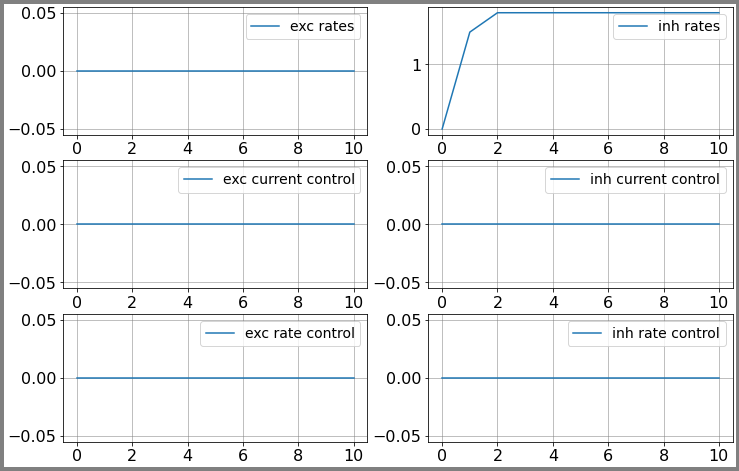

In [230]:
aln = RateModel()

aln.params.dt = 1.
aln.params['duration'] = 10.
control0 = aln.getZeroControl()
target = aln.getZeroTarget()
#control0 = step_control(maxI_ = 1.)

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.ext_exc_current = 0.

aln.params.c_gl =0.1*aln.params.c_gl

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroFullState()
plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

for i in range(len(state_vars)):
    state[:,i,:] = aln.state[state_vars[i]]

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]
        
high_state_vars[5] = 0.
high_state_vars[0] = 0.

In [8]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]
                    

In [9]:
tol = 1e-18

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

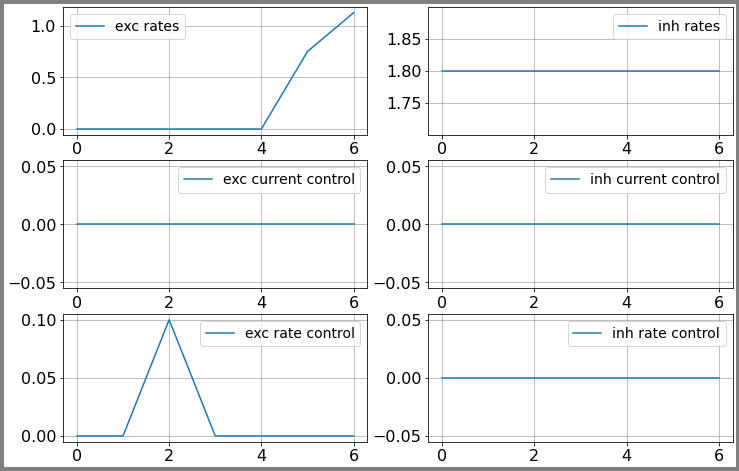

[[0.         0.         0.         0.30864198 0.15432099 0.07716049
  0.10693873]]


In [260]:
dur = 6.
dur_pre = 0.
dur_post = 0.
aln.params.duration = dur

control_ind = 2
control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
#control0[0,control_ind,1] = -0.3
control0[0,control_ind,2] = 0.1
control0[0,control_ind,5] = -0.2
setinitvars(high_state_vars)

plotFunc.plot_traces(aln, control0)

print(aln.state["seem"])
# [[0.8863383  0.92141907 0.8817336  0.88375921 0.88493324]]

target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,:]
target[0,1,:] = aln.rates_inh[0,:]

In [261]:
cost.setParams(1., 0.0, 0.* 1e0)
max_cntrl = 100. * 5.

setinitvars(high_state_vars)
max_it = 500
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,:]
#control2[:,2,2] = - 0.3
#control2 = bestControlA_A2[:,:,:]

# "HS", "FR", "PR", "HZ"
cgv = "HZ"

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = [control_ind], prec_variables_ = [0,1])

print("grad c= ", grad[0,control_ind,:])

print("best control = ", bestControlA[0,control_ind,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.   -0.02 -0.01  0. 

set cost params
RUN  0 , total integrated cost =  0.9140625000000007
RUN  1 , total integrated cost =  0.1459184338043275
RUN  2 , total integrated cost =  0.10368503571894747
RUN  3 , total integrated cost =  0.013450531067827133
RUN  4 , total integrated cost =  0.011203341999692893
RUN  5 , total integrated cost =  0.005582264249629168
RUN  6 , total integrated cost =  0.0014312080225280701
RUN  7 , total integrated cost =  0.0007350518983853537
RUN  8 , total integrated cost =  0.0006512727188002445
RUN  9 , total integrated cost =  0.00029158081155190657
RUN  10 , total integrated cost =  0.00014131279682372456
RUN  11 , total integrated cost =  0.00013094640048908556
RUN  12 , total integrated cost =  0.00010531967772809256
RUN  13 , total integrated cost =  9.92899448704836e-05
RUN  14 , total integrated cost =  8.46461077805653e-05
RUN  15 , total integrated cost =  4.4981341199711864e-05
RUN  16 , total integrated cost =  3.9663132443093334e-05
RUN  17 , total integrated cost 

RUN  148 , total integrated cost =  4.988999597618409e-12
RUN  149 , total integrated cost =  4.8462787124060874e-12
RUN  150 , total integrated cost =  4.706728294307174e-12
RUN  151 , total integrated cost =  4.576288360790692e-12
RUN  152 , total integrated cost =  4.447042475489539e-12
RUN  153 , total integrated cost =  4.3218388116601134e-12
RUN  154 , total integrated cost =  4.201928275916782e-12
RUN  155 , total integrated cost =  4.081058308497587e-12
RUN  156 , total integrated cost =  3.964108859343395e-12
RUN  157 , total integrated cost =  3.8538218246768164e-12
RUN  158 , total integrated cost =  3.745461267879252e-12
RUN  159 , total integrated cost =  3.6396472054536144e-12
RUN  160 , total integrated cost =  3.5390729521914247e-12
RUN  161 , total integrated cost =  3.4367224999597244e-12
RUN  162 , total integrated cost =  3.3387015794992474e-12
RUN  163 , total integrated cost =  3.245461680935327e-12
RUN  164 , total integrated cost =  3.1546010388613984e-12
RUN  1

RUN  296 , total integrated cost =  7.495518356306465e-14
RUN  297 , total integrated cost =  7.288872133106854e-14
RUN  298 , total integrated cost =  7.089327471181018e-14
RUN  299 , total integrated cost =  6.894772511577416e-14
RUN  300 , total integrated cost =  6.70539472101816e-14
RUN  301 , total integrated cost =  6.52228783457503e-14
RUN  302 , total integrated cost =  6.342459709406969e-14
RUN  303 , total integrated cost =  6.15855603934107e-14
RUN  304 , total integrated cost =  5.983354736534628e-14
RUN  305 , total integrated cost =  5.815953622855688e-14
RUN  306 , total integrated cost =  5.653512416636751e-14
RUN  307 , total integrated cost =  5.4924451019726617e-14
RUN  308 , total integrated cost =  5.333817209841895e-14
RUN  309 , total integrated cost =  5.18643405681097e-14
RUN  310 , total integrated cost =  5.0395571806310206e-14
RUN  311 , total integrated cost =  4.8980419024520236e-14
RUN  312 , total integrated cost =  4.761806487608496e-14
RUN  313 , tota

RUN  451 , total integrated cost =  9.039337148202918e-16
RUN  452 , total integrated cost =  8.787914990583225e-16
RUN  453 , total integrated cost =  8.536111444892262e-16
RUN  454 , total integrated cost =  8.290773118381468e-16
RUN  455 , total integrated cost =  8.06075621578097e-16
RUN  456 , total integrated cost =  7.833494332326047e-16
RUN  457 , total integrated cost =  7.612735232151818e-16
RUN  458 , total integrated cost =  7.401853955664595e-16
RUN  459 , total integrated cost =  7.188585906383257e-16
RUN  460 , total integrated cost =  6.982957154699662e-16
RUN  461 , total integrated cost =  6.788462583062623e-16
RUN  462 , total integrated cost =  6.59790373196203e-16
RUN  463 , total integrated cost =  6.411239905494175e-16
RUN  464 , total integrated cost =  6.224989004218014e-16
RUN  465 , total integrated cost =  6.053370243809432e-16
RUN  466 , total integrated cost =  5.887649542711764e-16
RUN  467 , total integrated cost =  5.726072469572416e-16
RUN  468 , total

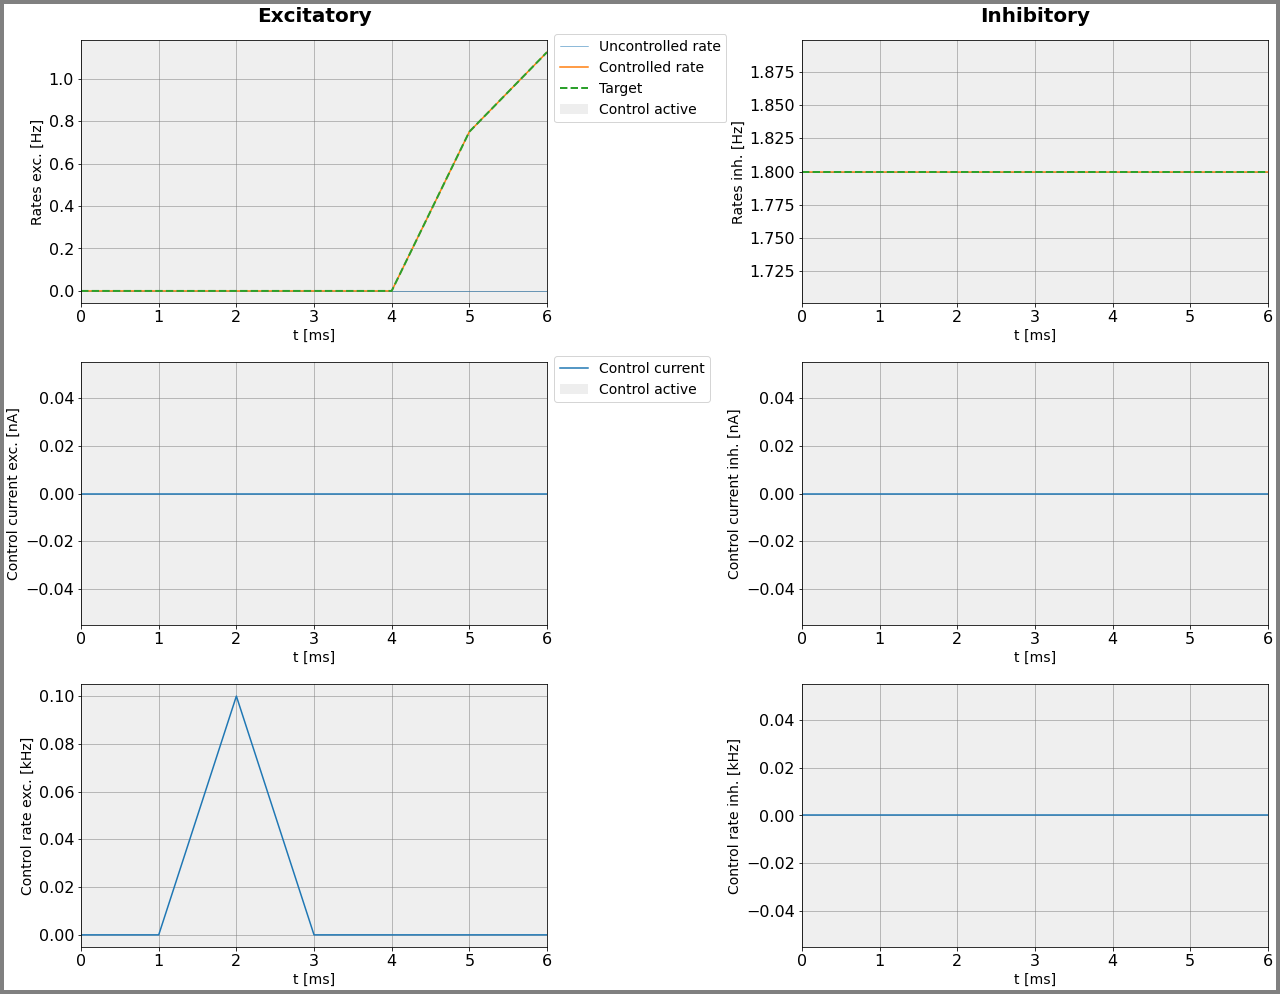

In [262]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

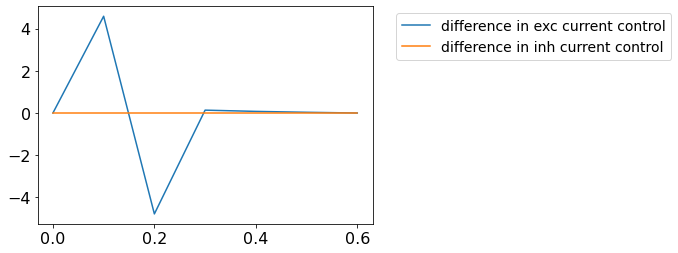

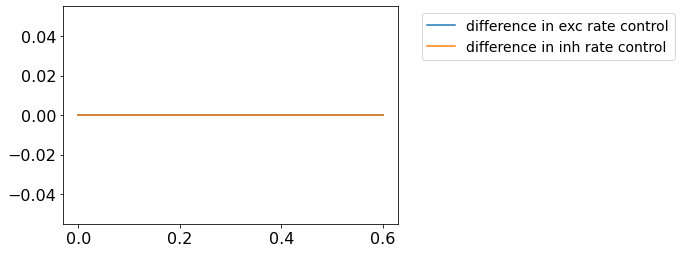

In [752]:
diff = control0 - bestControlA
#diff[0,2,-2:] = 0.

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [256]:
setinitvars(high_state_vars)
max_it = 100
start_step = 10.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-8

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA_A2[:,:,:]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control1, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, control_variables_ = [control_ind])

RUN  0 , total integrated cost:  0.9140625000000007
RUN  1 , total integrated cost:  0.2525258019808264
RUN  2 , total integrated cost:  0.10529951950831809
RUN  3 , total integrated cost:  0.047182311028618355
RUN  4 , total integrated cost:  0.024059008961091765
RUN  5 , total integrated cost:  0.014209698699833836
RUN  6 , total integrated cost:  0.009598366156732407
RUN  7 , total integrated cost:  0.007236481368182773
RUN  8 , total integrated cost:  0.0058170819125486686
RUN  9 , total integrated cost:  0.00490714586951072
RUN  10 , total integrated cost:  0.004182100069583202
RUN  11 , total integrated cost:  0.003608498642835062
RUN  12 , total integrated cost:  0.0030879781017686737
RUN  13 , total integrated cost:  0.0026620059226236995
RUN  14 , total integrated cost:  0.0022705615486453682
RUN  15 , total integrated cost:  0.0019425367352940079
RUN  16 , total integrated cost:  0.001647301894623724
RUN  17 , total integrated cost:  0.0013986853277127341
RUN  18 , total inte

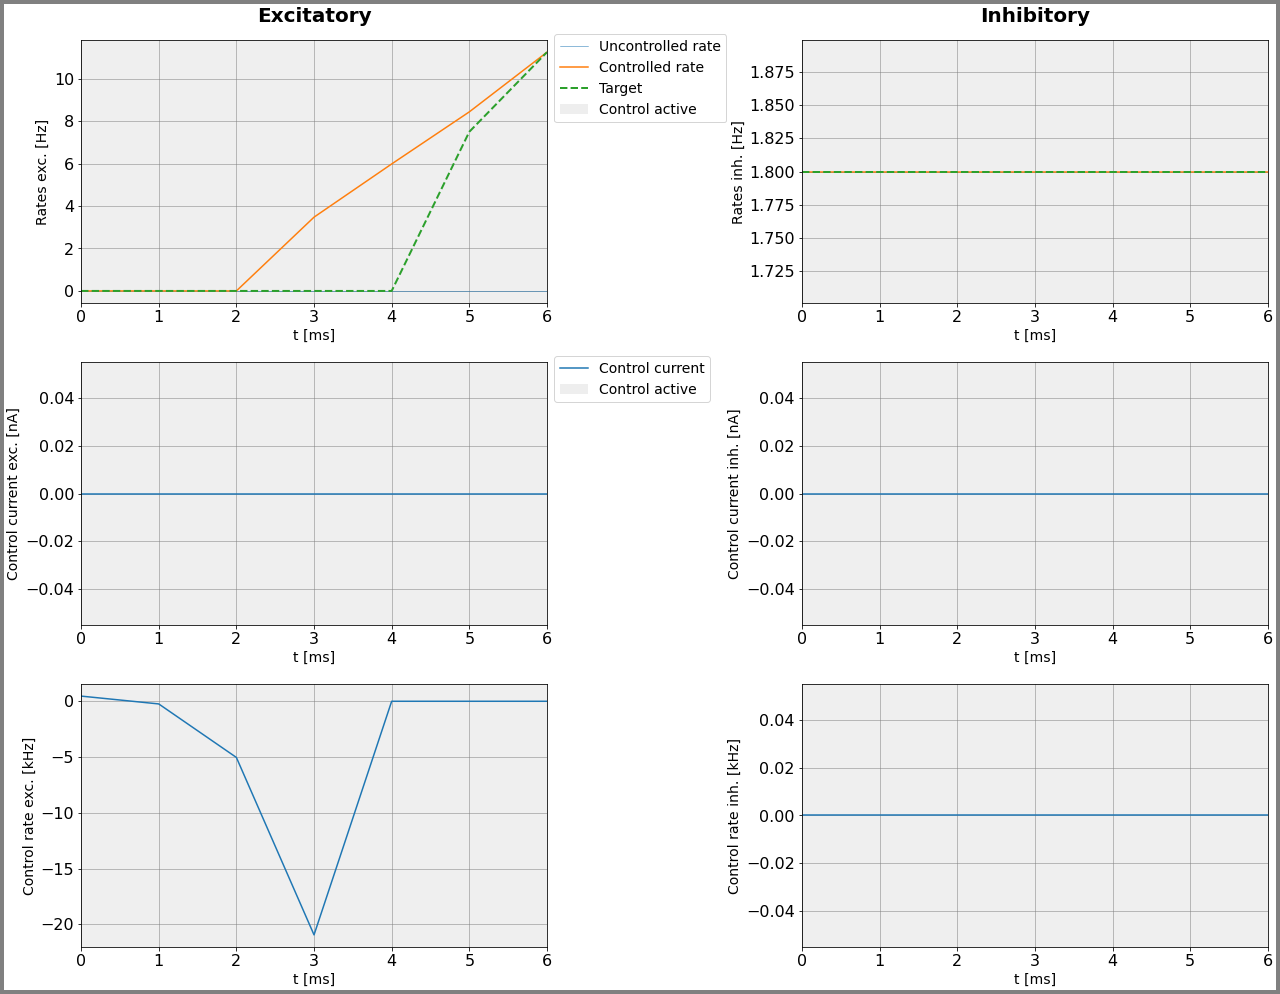

In [248]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

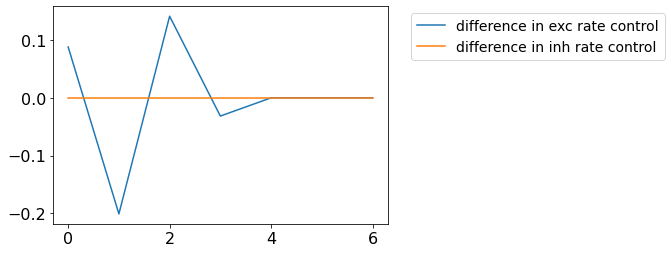

In [227]:
diff = control0 - bestControlA_A2
diff[0,2,-2:] = 0.

t = np.arange(0,dur+aln.params.dt, aln.params.dt)

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

-0.0004884455958080736


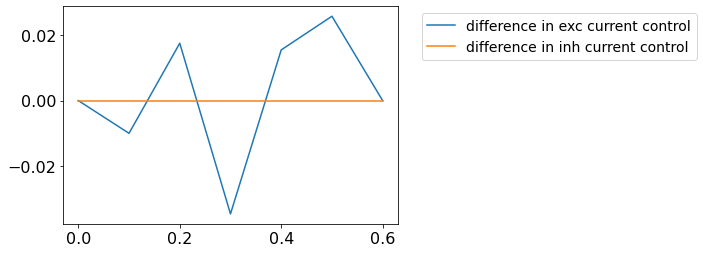

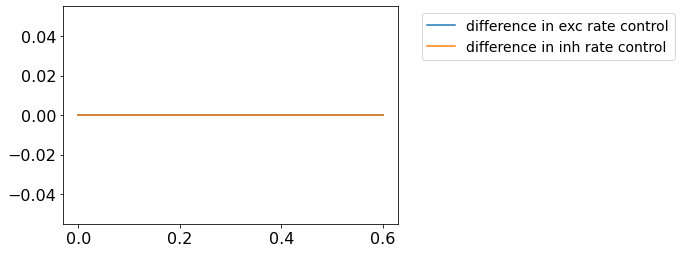

In [29]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

c_diff = costA_A2[6] - costA[3]
print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()